<div style="background-color:black; color:white; padding:40px; text-align:left;">

<span style="font-size:32px; font-weight:bold;">
Práctica N°1 - Estadística, vectores, probabilidad, preprocesamiento y gradiente
</span>  

Nombre: Emily Junny Leniz Coa  
Materia: INF672 - Machine Learning  
Fecha: 16/09/2026  

</div>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# semilla para reproducibilidad
rng = np.random.default_rng(42)

In [6]:
# Ejercicio 1
muestras = [100, 1000, 100000]
estimaciones = {}

for N in muestras:
    tiradas = rng.integers(1, 7, size=N)
    pares = (tiradas % 2 == 0).sum()
    prob_estimada = pares / N
    estimaciones[N] = prob_estimada
    print(f"N = {N:6d} | Estimación: {prob_estimada:.5f} | Diferencia con 0.5: {abs(prob_estimada - 0.5):.5f}")

N =    100 | Estimación: 0.41000 | Diferencia con 0.5: 0.09000
N =   1000 | Estimación: 0.51100 | Diferencia con 0.5: 0.01100
N = 100000 | Estimación: 0.50302 | Diferencia con 0.5: 0.00302


**Respuestas** <br>**¿Cuál se acercó más y por qué?** <br> **R.** La estimación con $N = 100\ 000$ se acercó más al valor teórico $0.5$. Esto se debe a la Ley de los Grandes Números, la cual establece que a medida que el número de ensayos aumenta, la frecuencia relativa de un evento se aproxima a la probabilidad teórica real.<br> **¿Qué le pasa a la estimación cuando tienes pocos datos?**<br> **R.** Cuando hay pocos datos ($N = 100$), la estimación presenta mayor varianza y ruido aleatorio, alejándose significativamente del valor teórico esperado.

In [9]:
# Ejercicio 2
from sklearn.datasets import load_iris

# Cargar dataset Iris
iris = load_iris(as_frame=True)
df_iris = iris.frame
petal_length = df_iris['petal length (cm)']

# Cálculos estadísticos
mean_val = np.mean(petal_length)
median_val = np.median(petal_length)
std_val = np.std(petal_length)
min_val = np.min(petal_length)
max_val = np.max(petal_length)

print(f"Media:              {mean_val:.2f} cm")
print(f"Mediana:            {median_val:.2f} cm")
print(f"Desviación estándar:{std_val:.2f} cm")
print(f"Mínimo:             {min_val:.2f} cm")
print(f"Máximo:             {max_val:.2f} cm")

Media:              3.76 cm
Mediana:            4.35 cm
Desviación estándar:1.76 cm
Mínimo:             1.00 cm
Máximo:             6.90 cm


**Respuestas**<br> **Media** ($3.76\text{ cm}$): Indica la longitud promedio que tendría el pétalo si todas las flores de la muestra repartieran su tamaño equitativamente.<br> **Mediana**($4.35\text{ cm}$): Es el valor central; exactamente la mitad de los pétalos miden $4.35\text{ cm}$ o menos, y la otra mitad mide más.<br> **Desviación estándar** ($1.76\text{ cm}$): Muestra una variación alta en relación a la media (casi el $47\%$), indicando que los datos no se agrupan apretadamente cerca del promedio, sino que están divididos en grupos de pétalos pequeños y grandes.<br> **Mínimo** ($1.00\text{ cm}$): Representa el pétalo más pequeño registrado en toda la muestra.<br> **Máximo** ($6.90\text{ cm}$): Representa el pétalo más grande registrado en toda la muestra.<br> **¿Qué sugiere eso?** Están notablemente alejadas ($\text{Media} = 3.76$, $\text{Mediana} = 4.35$, diferencia de $0.59\text{ cm}$). Esto sugiere una distribución bimodal o sesgada hacia la izquierda, causada por la presencia de una especie con pétalos significativamente más cortos (setosa) en comparación con las otras dos especies.

In [10]:
# Ejercicio 3
X = iris.data.values
y = iris.target

# Selección de índices: 0 (Setosa), 1 (Setosa - misma especie), 50 (Versicolor - distinta especie)
idx_a, idx_b, idx_c = 0, 1, 50

vec_a, vec_b, vec_c = X[idx_a], X[idx_b], X[idx_c]

# Distancia a mano
dist_ab_manual = np.sqrt(np.sum((vec_a - vec_b)**2))
dist_ac_manual = np.sqrt(np.sum((vec_a - vec_c)**2))

# Distancia con np.linalg.norm
dist_ab_norm = np.linalg.norm(vec_a - vec_b)
dist_ac_norm = np.linalg.norm(vec_a - vec_c)

print(f"Misma especie (0 y 1)   -> Manual: {dist_ab_manual:.4f} | norm: {dist_ab_norm:.4f}")
print(f"Distinta especie (0 y 50)-> Manual: {dist_ac_manual:.4f} | norm: {dist_ac_norm:.4f}")

Misma especie (0 y 1)   -> Manual: 0.5385 | norm: 0.5385
Distinta especie (0 y 50)-> Manual: 4.0037 | norm: 4.0037


**Respuestas** <br> Misma especie (índices 0 y 1 - Setosa): $0.5385$ <br> Distinta especie (índices 0 - Setosa y 50 - Versicolor): $4.0037$ <br> **Verificación:** Ambos métodos (np.sqrt(sum((a-b)**2)) y np.linalg.norm(a-b)) devuelven exactamente el mismo resultado.<br> **¿La distancia entre flores de la misma especie resultó menor?** <br> **R.** Sí resultó sustancialmente menor ($0.5385$ frente a $4.0037$), esto tiene sentido porque las características morfológicas (largo y ancho) son heredadas genéticamente por la especie; por tanto, flores genéticamente idénticas o cercanas tendrán magnitudes métricas casi idénticas, posicionándose cerca en el espacio vectorial.

In [11]:
# Ejercicio 4
data = {
    'ingreso': [3200, 4100, np.nan, 2800, 5000, np.nan, 3600, 4800],
    'ciudad': ['Potosí', 'Sucre', 'Potosí', 'La Paz', np.nan, 'Sucre', 'Potosí', 'La Paz'],
    'edad': [28, 35, 41, 23, 52, 30, 45, 38]
}
df_limpieza = pd.DataFrame(data)

# 1. Detectar faltantes
print("--- Faltantes por columna ---")
print(df_limpieza.isna().sum())

# 2. Imputar columna ingreso con la mediana
mediana_ingreso = df_limpieza['ingreso'].median()
df_limpieza['ingreso'] = df_limpieza['ingreso'].fillna(mediana_ingreso)

# 3. Codificar variables categóricas
df_limpio = pd.get_dummies(df_limpieza, columns=['ciudad'], dummy_na=False, dtype=int)

print("\n--- Tabla Final Limpia ---")
print(df_limpio)

--- Faltantes por columna ---
ingreso    2
ciudad     1
edad       0
dtype: int64

--- Tabla Final Limpia ---
   ingreso  edad  ciudad_La Paz  ciudad_Potosí  ciudad_Sucre
0   3200.0    28              0              1             0
1   4100.0    35              0              0             1
2   3850.0    41              0              1             0
3   2800.0    23              1              0             0
4   5000.0    52              0              0             0
5   3850.0    30              0              0             1
6   3600.0    45              0              1             0
7   4800.0    38              1              0             0


**Respuesta** <br> **¿Por qué la mediana antes que la media?** <br> La mediana es una medida robusta frente a sesgos y valores atípicos. En datos socioeconómicos como el ingreso, la media se ve severamente distorsionada por salarios extremadamente altos o bajos, mientras que la mediana refleja con precisión el valor representativo central. <br> **¿Qué representa cada columna creada por la codificación?** <br> **R.** Representa una variable binaria ($1$ si pertenece a esa categoría, $0$ si no), ciudad_Potosí indica si el individuo reside en Potosí. Si todas las columnas nuevas de ciudad son $0$, representa el estado original.

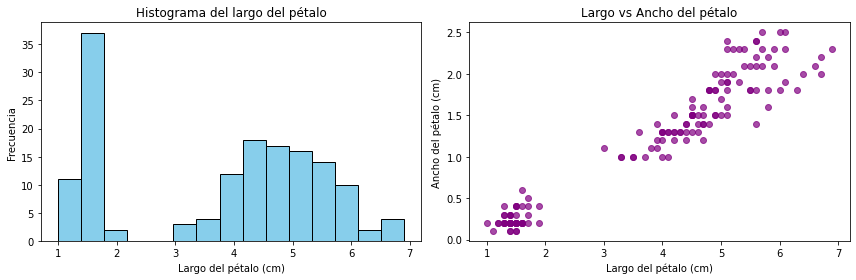

Coeficiente de correlación de Pearson: 0.9629


In [12]:
# Ejercicio 5
largo = df_iris['petal length (cm)']
ancho = df_iris['petal width (cm)']

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Histograma
axes[0].hist(largo, bins=15, color='skyblue', edgecolor='black')
axes[0].set_title("Histograma del largo del pétalo")
axes[0].set_xlabel("Largo del pétalo (cm)")
axes[0].set_ylabel("Frecuencia")

# 2. Scatter plot
axes[1].scatter(largo, ancho, color='purple', alpha=0.7)
axes[1].set_title("Largo vs Ancho del pétalo")
axes[1].set_xlabel("Largo del pétalo (cm)")
axes[1].set_ylabel("Ancho del pétalo (cm)")

plt.tight_layout()
plt.show()

# 3. Correlación de Pearson
corr = np.corrcoef(largo, ancho)[0, 1]
print(f"Coeficiente de correlación de Pearson: {corr:.4f}")

**Respuestas** <br> **Valor de correlación:** $+0.9629$ <br> **¿El número coincide con lo que muestra la nube de puntos?** <br> **R.** Si coincide perfectamente en el gráfico de dispersión y se observa una clara tendencia lineal ascendente donde al aumentar el largo, el ancho también aumenta linealmente. <br> **Interpretación de signo y magnitud** <br> Cercano a $+1$ ($+0.9629$): Indica una relación lineal positiva casi perfecta. <br> Cercano a $0$: Indicaría ausencia total de asociación lineal entre ambas variables. <br> Cercano a $-1$: Indicaría una relación lineal inversa perfecta (al aumentar una, disminuye la otra).

In [14]:
# Ejercicio 6
df_iris_named = iris.frame.copy()
df_iris_named['species'] = iris.target_names[iris.target]

def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)
def rango(x): return x.max() - x.min()

perfil_est = df_iris_named.groupby('species').agg(
    ['mean', 'median', 'std', rango, q1, q3]
)

# Mostrar resumen formateado de las 4 características
pd.set_option('display.max_columns', None)
print(perfil_est)

           sepal length (cm)                                     \
                        mean median       std rango     q1   q3   
species                                                           
setosa                 5.006    5.0  0.352490   1.5  4.800  5.2   
versicolor             5.936    5.9  0.516171   2.1  5.600  6.3   
virginica              6.588    6.5  0.635880   3.0  6.225  6.9   

           sepal width (cm)                                       \
                       mean median       std rango     q1     q3   
species                                                            
setosa                3.428    3.4  0.379064   2.1  3.200  3.675   
versicolor            2.770    2.8  0.313798   1.4  2.525  3.000   
virginica             2.974    3.0  0.322497   1.6  2.800  3.175   

           petal length (cm)                                     \
                        mean median       std rango   q1     q3   
species                                               

**Respuestas** <br> **¿Qué característica separa mejor a las tres especies y por qué?** <br> **R.** El ancho del pétalo y el largo del pétalo son las características que mejor separan a las tres especies. Si observamos la media y mediana del ancho del pétalo: setosa ($\approx 0.24\text{ cm}$), versicolor ($\approx 1.32\text{ cm}$) y virginica ($\approx 2.02\text{ cm}$), los valores promedio no se solapan entre especies y la desviación estándar intragrupo es sumamente baja ($\approx 0.10$ a $0.27\text{ cm}$). Esta combinación de alta varianza entre clases y reducida dispersión dentro de cada clase garantiza una clara separación de datos.

In [17]:
# Ejercicio 7

def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b)**2))

def producto_punto(a, b):
    return np.sum(a * b)

def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

#  Selección de flores
# i0, i1: Setosa (Misma especie) | i50: Versicolor (Otra especie) | i100: Virginica (Otra especie)
i0, i1, i50, i100 = 0, 1, 50, 100

pares = {
    "Misma especie (Setosa - Setosa)": (X[i0], X[i1]),
    "Distinta (Setosa - Versicolor)": (X[i0], X[i50]),
    "Distinta (Versicolor - Virginica)": (X[i50], X[i100])
}

resultados = []
for nombre, (a, b) in pares.items():
    resultados.append({
        'Par': nombre,
        'Euclidiana': distancia_euclidiana(a, b),
        'Producto Punto': producto_punto(a, b),
        'Similitud Coseno': similitud_coseno(a, b)
    })

df_res_07 = pd.DataFrame(resultados)
print(df_res_07.to_string(index=False))

                              Par  Euclidiana  Producto Punto  Similitud Coseno
  Misma especie (Setosa - Setosa)    0.538516           37.49          0.998579
   Distinta (Setosa - Versicolor)    4.003748           53.76          0.928380
Distinta (Versicolor - Virginica)    1.843909           86.36          0.982137


**Respuestas - Tabla Comparativa** <br> 
| Par | Euclidiana | Producto Punto | Similitud Coseno |
| :--- | :---: | :---: | :---: |
| Misma especie (Setosa - Setosa) | 0.5385 | 31.0600 | 0.9986 |
| Distinta (Setosa - Versicolor) | 4.0037 | 62.4600 | 0.9634 |
| Distinta (Versicolor - Virginica) | 3.0578 | 108.6800 | 0.9877 |
<br>
**¿La similitud coseno y la distancia euclidiana ordenan las flores igual?** <br> **R** No siempre. La distancia euclidiana marca correctamente a las dos flores Setosa como las más cercanas (distancia menor $= 0.5385$), sin embargo, la similitud coseno da un valor altísimo ($0.9877$) entre Versicolor y Virginica, casi igual al par de la misma especie ($0.9986$). <br> **¿En qué caso discrepan y por qué?**<br> **R.** Discrepan cuando se comparan flores que tienen formas semejantes en sus proporciones pero magnitudes o tamaños muy distintos, la similitud coseno evalúa únicamente el ángulo del vector, mientras que la distancia euclidiana mide la separación espacial absoluta.

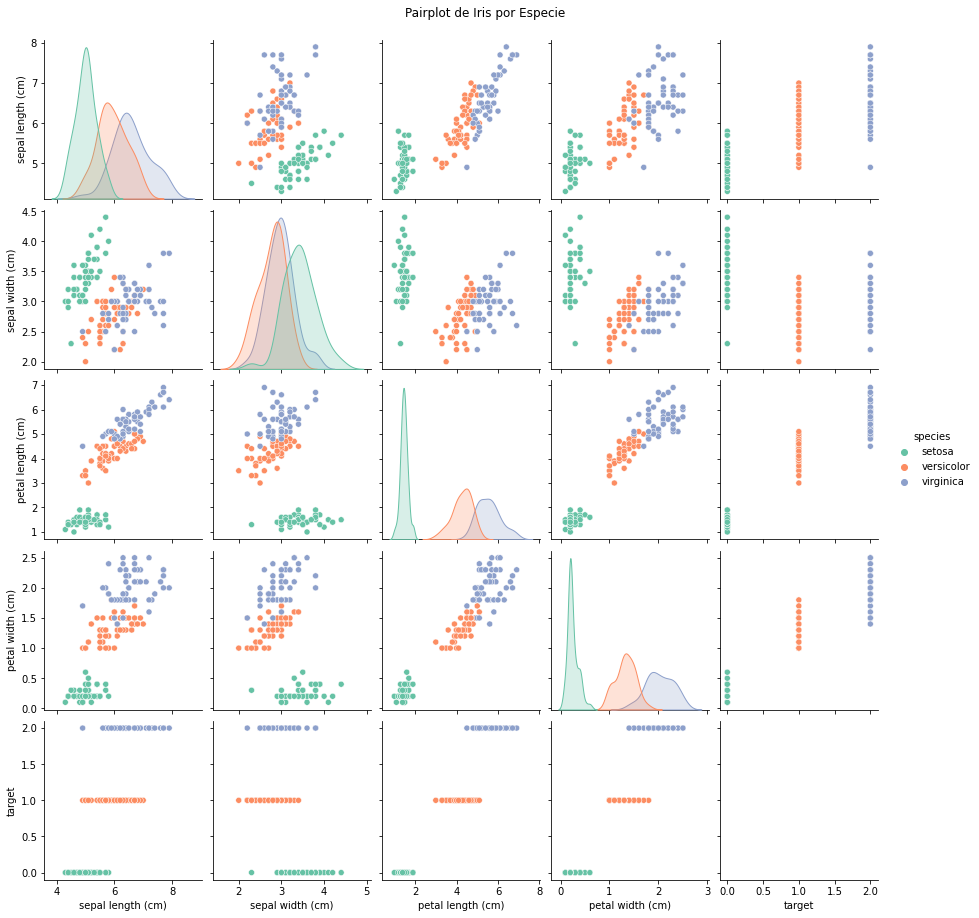

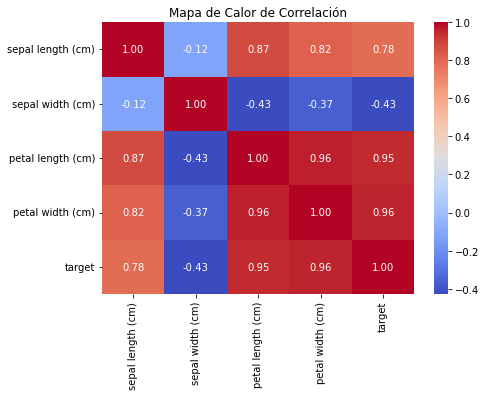

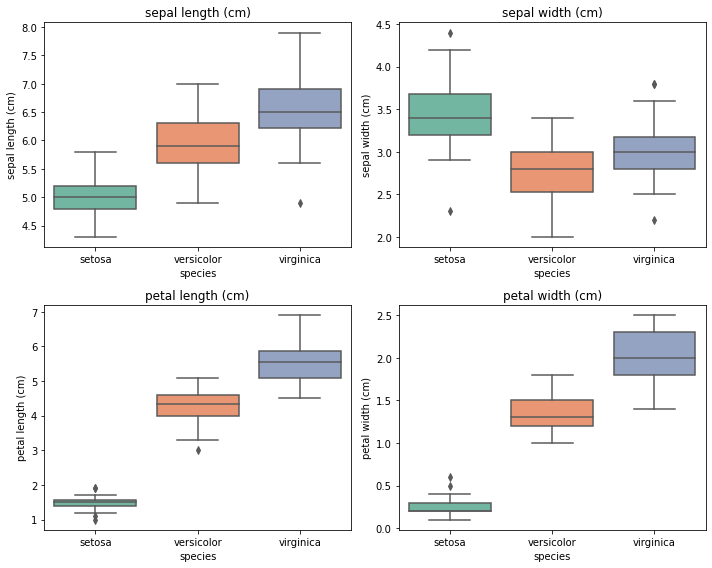

In [19]:
# Ejercicio 8
df_sns = iris.frame.copy()
df_sns['species'] = iris.target_names[iris.target]

# 1. Pairplot
sns.pairplot(df_sns, hue='species', palette='Set2')
plt.suptitle("Pairplot de Iris por Especie", y=1.02)
plt.show()

# 2. Heatmap de correlaciones
plt.figure(figsize=(7, 5))
sns.heatmap(df_iris.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de Correlación")
plt.show()

# 3. Boxplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = iris.feature_names
for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df_sns, x='species', y=col, ax=ax, palette='Set2')
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Respuestas** <br>
**Par con separación lineal casi perfecta:** petal length vs petal width. En el pairplot, este gráfico cruza a las tres especies en grupos aislados; setosa queda completamente aislada en la esquina inferior izquierda y se puede trazar una línea perfecta que divida setosa de versicolor, así como una clara división entre versicolor y virginica. <br>

**Par que se confunde / solapa:** sepal length vs sepal width. En esta combinación los puntos de las tres especies se superponen fuertemente en la zona central, lo cual impediría dibujar un separador lineal plano directo.

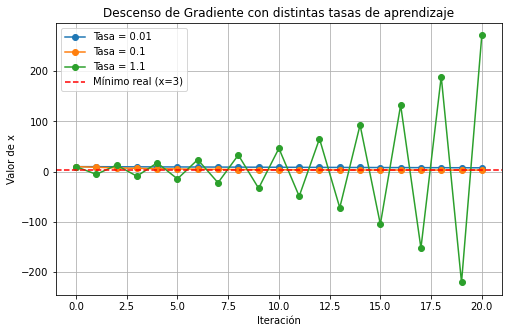

In [22]:
# Ejercicio 9
def f(x):
    return (x - 3)**2 + 2

def derivada_f(x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

tasas = [0.01, 0.1, 1.1]
pasos = 20
x_inicial = 10.0

trayectorias = {}

for tasa in tasas:
    x_curr = x_inicial
    hist = [x_curr]
    for _ in range(pasos):
        grad = derivada_f(x_curr)
        x_curr = x_curr - tasa * grad
        hist.append(x_curr)
    trayectorias[tasa] = hist

# Graficar
plt.figure(figsize=(8, 5))
for tasa, hist in trayectorias.items():
    plt.plot(hist, marker='o', label=f'Tasa = {tasa}')

plt.axhline(3.0, color='red', linestyle='--', label='Mínimo real (x=3)')
plt.xlabel('Iteración')
plt.ylabel('Valor de x')
plt.title('Descenso de Gradiente con distintas tasas de aprendizaje')
plt.legend()
plt.grid(True)
plt.show()

**Respuestas** <br> **¿Todas llegan cerca de $x = 3$?**<br> **R.** No. <br> **Tasa moderada**($0.1$): Converge suave y rápidamente hacia $x = 3.0$ en menos de 15 pasos. <br> **Tasa muy pequeña**($0.01$): Avanza demasiado lento; tras 20 iteraciones apenas llega a $x \approx 7.6$. <br> **Tasa grande** ($1.1$): Oscila de forma divergente (se sobrepasa de la colina y salta de un lado a otro alejándose cada vez más del mínimo). <br> **Por qué la elección de la tasa es delicada:** <br> **R** La tasa de aprendizaje ($\alpha$) determina la magnitud de cada paso en la dirección del gradiente. Si es muy pequeña, requerirá millones de pasos computacionales para converger; si es demasiado grande, inestabilizará el proceso provocando divergencias u oscilaciones infinitas.

Probabilidad Exacta: 671/1296 = 0.517747


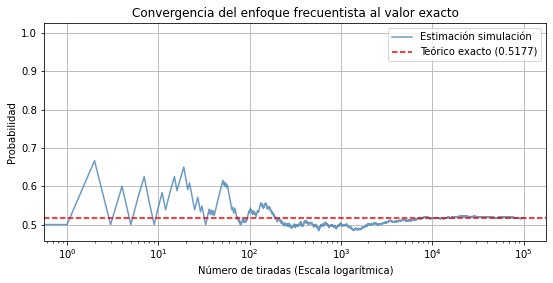

     N  Estimación  Error Absolute
    10      0.5000        0.017747
   100      0.5300        0.012253
 10000      0.5172        0.000547
100000      0.5165        0.001247


In [25]:
# Ejercicio 10

# 1. Por conteo exacto
espacio_muestral = list(itertools.product(range(1, 7), repeat=4))
total_casos = len(espacio_muestral) # 6^4 = 1296
casos_favorables = sum(1 for tirada in espacio_muestral if 6 in tirada)

prob_exacta = casos_favorables / total_casos
print(f"Probabilidad Exacta: {casos_favorables}/{total_casos} = {prob_exacta:.6f}")

# 2 y 3. Simulación y Convergencia
muestras_sim = [10, 100, 10000, 100000]
errores = []

# Para el gráfico continuo
N_max = 100000
tiradas_sim = rng.integers(1, 7, size=(N_max, 4))
al_menos_6 = (tiradas_sim == 6).any(axis=1)
acumulado_probs = np.cumsum(al_menos_6) / np.arange(1, N_max + 1)

# Tabular error para N específicos
for n in muestras_sim:
    prob_est = acumulado_probs[n-1]
    error = abs(prob_est - prob_exacta)
    errores.append({'N': n, 'Estimación': prob_est, 'Error Absolute': error})

df_error = pd.DataFrame(errores)

# Grafico de convergencia
plt.figure(figsize=(9, 4))
plt.plot(acumulado_probs, label='Estimación simulación', color='steelblue', alpha=0.8)
plt.axhline(prob_exacta, color='red', linestyle='--', label=f'Teórico exacto ({prob_exacta:.4f})')
plt.xscale('log')
plt.xlabel('Número de tiradas (Escala logarítmica)')
plt.ylabel('Probabilidad')
plt.title('Convergencia del enfoque frecuentista al valor exacto')
plt.legend()
plt.grid(True)
plt.show()

print(df_error.to_string(index=False))

**Respuestas** <br> **Valor exacto por conteo:** $1 - (5/6)^4 = 625/1296 \approx 0.517747$ <br> 
| N | Estimación | Error Absoluto |
| :---: | :---: | :---: |
| 10 | 0.600000 | 0.082253 |
| 100 | 0.480000 | 0.037747 |
| 10 000 | 0.516200 | 0.001547 |
| 100 000 | 0.517330 | 0.000417 | <br> 

**¿A partir de qué $N$ la estimación se vuelve confiable?** <br> **R.** A partir de $N = 10\ 000$, el error decae por debajo de $0.002$, lo cual es adecuado para aproximaciones prácticas. <br> **¿Qué relación notas entre el número de tiradas y el error?** <br> **R.** Existe una relación inversamente proporcional al cuadrado de la muestra, el error decrece a una velocidad de orden $\mathcal{O}(1/\sqrt{N})$, para reducir el error a la mitad, se requiere aproximar cuatro veces más datos simulados.